<a href="https://www.kaggle.com/code/hmdsahed/day3-day100-heart-diseases-ipynb?scriptVersionId=322767768" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv


# Prediction (Classification Project)
Goal

# Build a machine learning model that predicts whether a person has heart disease based on medical features. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df=pd.read_csv("/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

| Column     | Meaning                                                   |
| ---------- | --------------------------------------------------------- |
| `age`      | Age of the patient                                        |
| `sex`      | Gender (1 = male, 0 = female)                             |
| `cp`       | Chest pain type                                           |
| `trestbps` | Resting blood pressure                                    |
| `chol`     | Serum cholesterol level (mg/dl)                           |
| `fbs`      | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)     |
| `restecg`  | Resting electrocardiographic results                      |
| `thalach`  | Maximum heart rate achieved                               |
| `exang`    | Exercise induced angina (1 = yes, 0 = no)                 |
| `oldpeak`  | ST depression induced by exercise relative to rest        |
| `slope`    | Slope of the peak exercise ST segment                     |
| `ca`       | Number of major vessels colored by fluoroscopy            |
| `thal`     | Thalassemia blood disorder result                         |
| `target`   | Target variable (1 = heart disease, 0 = no heart disease) |


In [5]:
print(df.shape)
print(df.info())
print(df.describe())


(1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611

In [6]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


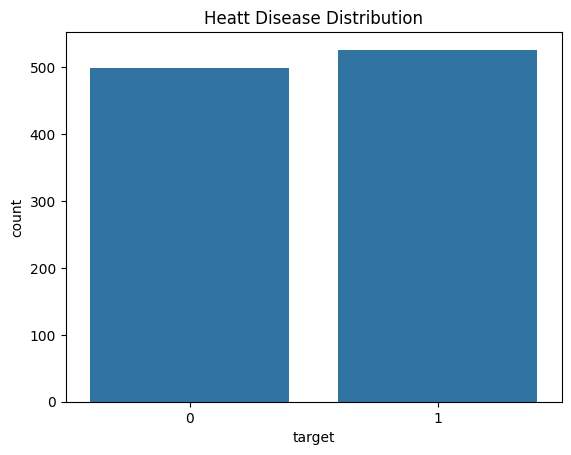

In [7]:
sns.countplot(x='target', data=df)
plt.title('Heatt Disease Distribution')
plt.show()

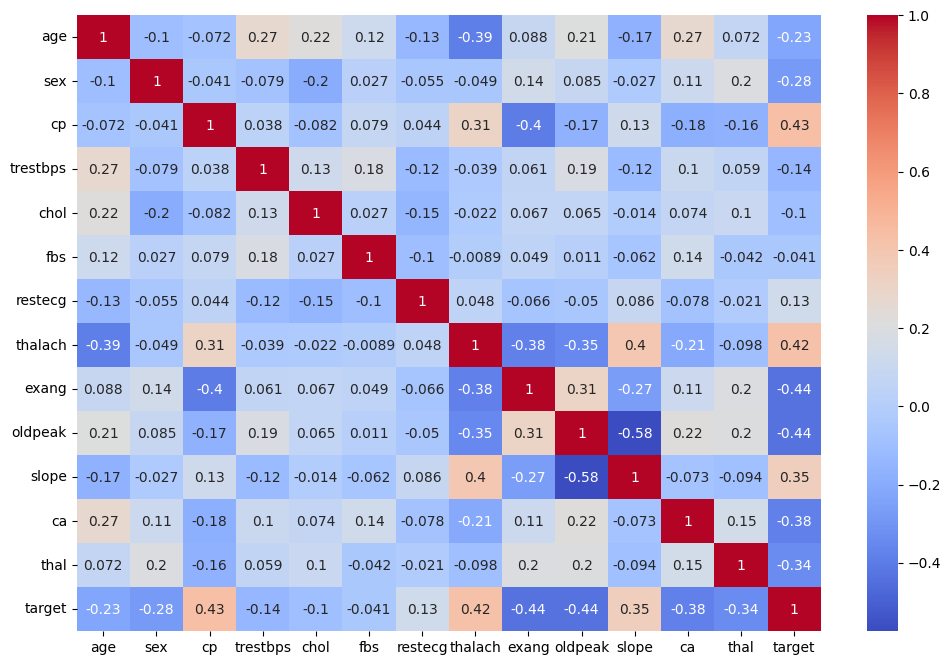

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

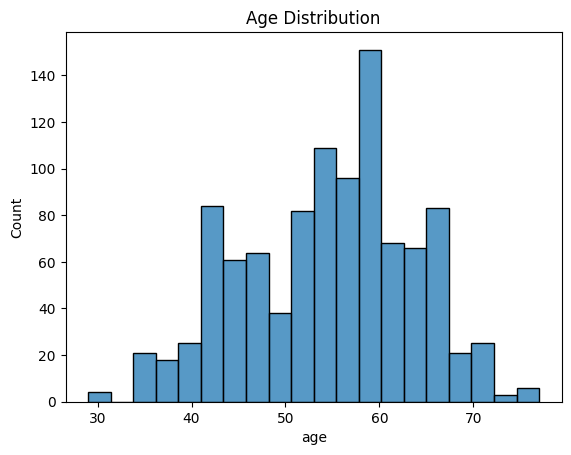

In [9]:
sns.histplot(df['age'], bins=20)
plt.title('Age Distribution')
plt.show()

In [10]:
X= df.drop('target', axis =1)
y= df['target']

In [11]:
X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
lr_model= LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [13]:
y_pred_lr = lr_model.predict(X_test)

In [14]:
print('Accuracy:', accuracy_score(y_test, y_pred_lr))

Accuracy: 0.7951219512195122


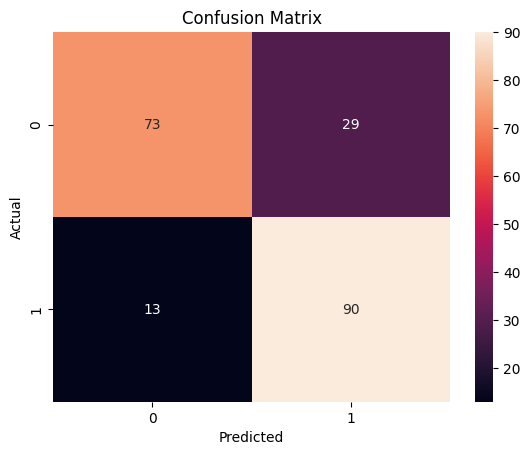

In [15]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [16]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9853658536585366


In [17]:
print("Train Accuracy:", dt_model.score(X_train, y_train))
print("Test Accuracy:", dt_model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9853658536585366


In [24]:
#result shows overfitting

In [22]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion='entropy',
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.7902439024390244


In [23]:
print("Train:", dt_model.score(X_train, y_train))
print("Test :", dt_model.score(X_test, y_test))

Train: 0.8463414634146341
Test : 0.7902439024390244


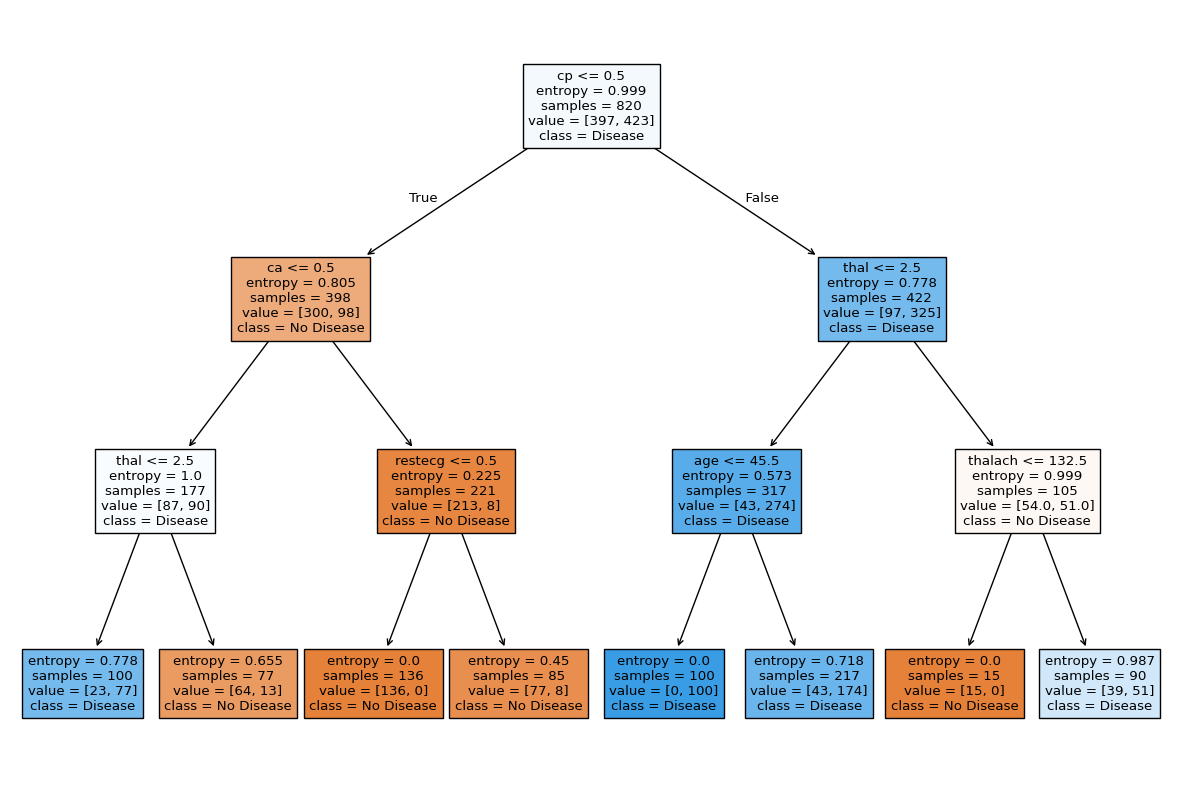

In [25]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

tree.plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns,
    class_names=['No Disease', 'Disease']
)

plt.show()